# Adaptive Pullback Momentum v1.0 — Backtest

Replicates the Pine Script strategy logic bar-by-bar.

### Strategy Summary
| Component | Value |
|---|---|
| **Entry trigger** | Prev-bar low tagged EMA21 (±0.3%), current bar recovers above it bullishly |
| **Macro filter** | close > EMA200 longs / close < EMA200 shorts |
| **Structure** | EMA21 > EMA50 longs / EMA21 < EMA50 shorts |
| **Momentum** | RSI 42–68 longs / 32–58 shorts |
| **Volume** | ≥ 1.0× VolSMA 20 |
| **Trend quality** | ADX > 20 |
| **Panic filter** | ATR14 < ATR60-SMA × 1.5 |
| **Stop loss** | Entry ± ATR × 1.5 |
| **Take profit** | Entry ± ATR × 2.5 (1.67:1 R:R) |
| **Trail** | Activates at ATR×1.0 profit → trails ATR×0.8 from best price |
| **Sizing** | 1% equity at risk per trade |
| **Capital** | $10,000 · Commission 0.06% |

In [1]:
# ── 0. Install dependencies ──────────────────────────────────────────────────
import subprocess, sys
for pkg in ["yfinance", "pandas", "numpy", "matplotlib"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")
print("Libraries ready")

Libraries ready


## 1 · Configuration
Change these values to test any instrument or timeframe.

In [2]:
# ── 1. Configuration ─────────────────────────────────────────────────────────
# ▸ Data
TICKER   = "BTC-USD"
PERIOD   = "60d"      # yfinance period string  (e.g. "60d", "180d", "1y")
INTERVAL = "30m"      # "1m","5m","15m","30m","1h","1d"

# ▸ Trend filters
EMA_FAST    = 21
EMA_MID     = 50
EMA_SLOW    = 200
ADX_THRESH  = 20
ADX_LEN     = 14
PB_PCT      = 0.30    # pullback tolerance in % (how close low must come to EMA_FAST)

# ▸ Momentum / volume
RSI_LEN     = 14
RSI_LO_L    = 42;  RSI_HI_L = 68   # RSI bounds for longs
RSI_LO_S    = 32;  RSI_HI_S = 58   # RSI bounds for shorts
VOL_LEN     = 20
VOL_MULT    = 1.0

# ▸ Volatility
ATR_LEN     = 14
PANIC_MULT  = 1.5    # ATR14 > ATR60SMA × this → no new entries

# ▸ Risk management
SL_MULT     = 1.5    # stop   = entry ± ATR × SL_MULT
TP_MULT     = 2.5    # target = entry ± ATR × TP_MULT  (1.67:1 R:R)
TRAIL_ACT   = 1.0    # trail activates once price moves ATR × TRAIL_ACT in favour
TRAIL_DIST  = 0.8    # once active, trail stays ATR × TRAIL_DIST from best price
RISK_PCT    = 0.01   # fraction of equity risked per trade

# ▸ Simulation
INITIAL_CAPITAL = 10_000.0
COMMISSION_PCT  = 0.0006   # 0.06 % per side

# ▸ Direction
TRADE_LONGS  = True
TRADE_SHORTS = True

print("Config loaded.")

Config loaded.


## 2 · Download Data

In [3]:
# ── 2. Download data ─────────────────────────────────────────────────────────
df = yf.download(TICKER, period=PERIOD, interval=INTERVAL, auto_adjust=True, progress=False)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

df = df[["Open", "High", "Low", "Close", "Volume"]].copy()
df.dropna(inplace=True)

print(f"Downloaded: {TICKER} {INTERVAL} | Rows: {len(df)}")
print(f"  Range: {df.index[0]}  →  {df.index[-1]}")
df.tail(3)

Downloaded: BTC-USD 30m | Rows: 2833
  Range: 2026-01-03 00:00:00+00:00  →  2026-03-03 02:30:00+00:00


Price,Open,High,Low,Close,Volume
Datetime,,,,,
2026-03-03 01:30:00+00:00,68915.187500,69023.539062,68799.007812,68807.179688,451600384
2026-03-03 02:00:00+00:00,68753.421875,68753.421875,68266.515625,68440.671875,1865256960
2026-03-03 02:30:00+00:00,68432.164062,68500.796875,68432.164062,68449.593750,217026560


## 3 · Indicator Calculation

In [4]:
# ── 3. Indicators ────────────────────────────────────────────────────────────

# EMA stack
df["EMA_FAST"] = df["Close"].ewm(span=EMA_FAST, adjust=False).mean()
df["EMA_MID"]  = df["Close"].ewm(span=EMA_MID,  adjust=False).mean()
df["EMA_SLOW"] = df["Close"].ewm(span=EMA_SLOW, adjust=False).mean()

# RSI (Wilder)
delta  = df["Close"].diff()
gain   = delta.clip(lower=0)
loss   = (-delta).clip(lower=0)
avg_g  = gain.ewm(alpha=1/RSI_LEN, adjust=False).mean()
avg_l  = loss.ewm(alpha=1/RSI_LEN, adjust=False).mean()
df["RSI"] = 100 - (100 / (1 + avg_g / avg_l.replace(0, 1e-10)))

# ATR (Wilder)
hl   = df["High"] - df["Low"]
hpc  = (df["High"] - df["Close"].shift(1)).abs()
lpc  = (df["Low"]  - df["Close"].shift(1)).abs()
tr   = pd.concat([hl, hpc, lpc], axis=1).max(axis=1)
df["ATR"]    = tr.ewm(alpha=1/ATR_LEN, adjust=False).mean()
df["ATR_BL"] = df["ATR"].rolling(60).mean()   # 60-bar ATR baseline

# Volume SMA
df["VOL_MA"] = df["Volume"].rolling(VOL_LEN).mean()

# ADX / DMI (Wilder)
up_move  = df["High"] - df["High"].shift(1)
dn_move  = df["Low"].shift(1) - df["Low"]
plus_dm  = np.where((up_move > dn_move) & (up_move > 0), up_move, 0.0)
minus_dm = np.where((dn_move > up_move) & (dn_move > 0), dn_move, 0.0)
s_plus   = pd.Series(plus_dm,  index=df.index).ewm(alpha=1/ADX_LEN, adjust=False).mean()
s_minus  = pd.Series(minus_dm, index=df.index).ewm(alpha=1/ADX_LEN, adjust=False).mean()
df["DI_PLUS"]  = 100 * s_plus  / df["ATR"]
df["DI_MINUS"] = 100 * s_minus / df["ATR"]
dx             = 100 * (df["DI_PLUS"] - df["DI_MINUS"]).abs() / (df["DI_PLUS"] + df["DI_MINUS"])
df["ADX"]      = dx.ewm(alpha=1/ADX_LEN, adjust=False).mean()

df.dropna(inplace=True)

# Regime flags
df["IS_TRENDING"] = df["ADX"] > ADX_THRESH
df["IS_PANIC"]    = df["ATR"] > df["ATR_BL"] * PANIC_MULT

print(f"Indicators ready. Clean rows: {len(df)}")
df[["Close","EMA_FAST","EMA_MID","EMA_SLOW","RSI","ATR","ADX","IS_TRENDING","IS_PANIC"]].tail(4)

Indicators ready. Clean rows: 2774


Price,Close,EMA_FAST,EMA_MID,EMA_SLOW,RSI,ATR,ADX,IS_TRENDING,IS_PANIC
Datetime,,,,,,,,,
2026-03-03 01:00:00+00:00,68981.625000,68437.689665,67577.196865,66692.391653,61.643029,480.532036,32.484158,True,False
2026-03-03 01:30:00+00:00,68807.179688,68471.279667,67625.431485,66713.434320,58.630000,462.246265,32.250002,True,False
2026-03-03 02:00:00+00:00,68440.671875,68468.497140,67657.401696,66730.620763,52.791611,467.847537,30.673583,True,False
2026-03-03 02:30:00+00:00,68449.593750,68466.778650,67688.468051,66747.724972,52.914530,439.332199,29.209764,True,False


## 4 · Entry Signals

In [5]:
# ── 4. Entry signals ─────────────────────────────────────────────────────────
tol = PB_PCT / 100.0

# Long  : prev bar's low ≤ EMA_FAST × (1 + tol)  AND  current close > EMA_FAST, close > open
long_pb  = (
    (df["Low"].shift(1) <= df["EMA_FAST"].shift(1) * (1 + tol)) &
    (df["Close"] > df["EMA_FAST"]) &
    (df["Close"] > df["Open"])
)

# Short : prev bar's high ≥ EMA_FAST × (1 - tol)  AND  current close < EMA_FAST, close < open
short_pb = (
    (df["High"].shift(1) >= df["EMA_FAST"].shift(1) * (1 - tol)) &
    (df["Close"] < df["EMA_FAST"]) &
    (df["Close"] < df["Open"])
)

df["LongSignal"] = (
    long_pb &
    (df["Close"]    > df["EMA_SLOW"]) &
    (df["EMA_FAST"] > df["EMA_MID"]) &
    (df["RSI"] >= RSI_LO_L) & (df["RSI"] <= RSI_HI_L) &
    (df["Volume"] >= df["VOL_MA"] * VOL_MULT) &
    df["IS_TRENDING"] & ~df["IS_PANIC"]
) & TRADE_LONGS

df["ShortSignal"] = (
    short_pb &
    (df["Close"]    < df["EMA_SLOW"]) &
    (df["EMA_FAST"] < df["EMA_MID"]) &
    (df["RSI"] >= RSI_LO_S) & (df["RSI"] <= RSI_HI_S) &
    (df["Volume"] >= df["VOL_MA"] * VOL_MULT) &
    df["IS_TRENDING"] & ~df["IS_PANIC"]
) & TRADE_SHORTS

print(f"Long  signals : {df['LongSignal'].sum():>4}")
print(f"Short signals : {df['ShortSignal'].sum():>4}")
print(f"Total         : {df['LongSignal'].sum() + df['ShortSignal'].sum():>4}")

Long  signals :   26
Short signals :   65
Total         :   91


## 5 · Backtest Simulation

In [6]:
# ── 5. Bar-by-bar backtest ────────────────────────────────────────────────────
equity       = INITIAL_CAPITAL
position     = None
trades       = []
equity_curve = []

for ts, row in df.iterrows():
    close = float(row["Close"])
    high  = float(row["High"])
    low   = float(row["Low"])
    atr   = float(row["ATR"])
    stop_dist = atr * SL_MULT

    hit_tp = hit_sl = False
    exit_px = None

    # ── Manage open position ──────────────────────────────────────────────────
    if position is not None:
        d = position["direction"]

        if d == "long":
            if high > position["best"]:
                position["best"] = high
            # Activate / update trailing stop
            if position["best"] >= position["entry"] + atr * TRAIL_ACT:
                candidate = position["best"] - atr * TRAIL_DIST
                position["sl"] = max(position["sl"], candidate)
            hit_tp = high >= position["tp"]
            hit_sl = low  <= position["sl"]
            if hit_tp or hit_sl:
                exit_px = position["tp"] if hit_tp else position["sl"]
                pnl_pct = (exit_px - position["entry"]) / position["entry"]

        else:  # short
            if low < position["best"]:
                position["best"] = low
            if position["best"] <= position["entry"] - atr * TRAIL_ACT:
                candidate = position["best"] + atr * TRAIL_DIST
                position["sl"] = min(position["sl"], candidate)
            hit_tp = low  <= position["tp"]
            hit_sl = high >= position["sl"]
            if hit_tp or hit_sl:
                exit_px = position["tp"] if hit_tp else position["sl"]
                pnl_pct = (position["entry"] - exit_px) / position["entry"]

        if hit_tp or hit_sl:
            dollar_pnl  = pnl_pct * position["notional"]
            commission  = position["notional"] * COMMISSION_PCT * 2
            dollar_pnl -= commission
            equity     += dollar_pnl
            trades.append({
                "entry_time" : position["entry_time"],
                "exit_time"  : ts,
                "direction"  : d,
                "entry"      : position["entry"],
                "exit"       : exit_px,
                "sl_initial" : position["sl_initial"],
                "tp"         : position["tp"],
                "result"     : "TP" if hit_tp else "SL",
                "pnl_pct"    : round(pnl_pct * 100, 3),
                "dollar_pnl" : round(dollar_pnl, 2),
                "equity"     : round(equity, 2),
            })
            position = None

    # ── New entry ─────────────────────────────────────────────────────────────
    if position is None:
        sig = None
        if   bool(row["LongSignal"]):  sig = "long"
        elif bool(row["ShortSignal"]): sig = "short"

        if sig:
            risk_cap = equity * RISK_PCT
            qty      = risk_cap / stop_dist
            notional = qty * close
            sl = close - stop_dist if sig == "long" else close + stop_dist
            tp = close + atr * TP_MULT if sig == "long" else close - atr * TP_MULT
            position = {
                "direction"  : sig,
                "entry"      : close,
                "entry_time" : ts,
                "sl"         : sl,
                "sl_initial" : sl,
                "tp"         : tp,
                "best"       : close,
                "notional"   : notional,
            }

    equity_curve.append({"time": ts, "equity": equity})

print(f"Simulation complete.  Trades: {len(trades)}")

Simulation complete.  Trades: 72


## 6 · Performance Statistics

In [7]:
# ── 6. Performance statistics ────────────────────────────────────────────────
tdf = pd.DataFrame(trades)

if tdf.empty:
    print("No trades executed — try relaxing ADX, RSI bounds or pullback tolerance.")
else:
    wins   = tdf[tdf["dollar_pnl"] > 0]
    losses = tdf[tdf["dollar_pnl"] <= 0]
    wr     = len(wins) / len(tdf) * 100
    total  = tdf["dollar_pnl"].sum()
    final  = tdf["equity"].iloc[-1]
    gp     = wins["dollar_pnl"].sum()   if not wins.empty   else 0
    gl     = losses["dollar_pnl"].sum() if not losses.empty else 0
    pf     = gp / abs(gl)               if gl != 0          else float("inf")

    eq_s   = pd.Series([e["equity"] for e in equity_curve])
    mdd    = ((eq_s - eq_s.cummax()) / eq_s.cummax() * 100).min()
    ret    = (final / INITIAL_CAPITAL - 1) * 100

    tp_cnt = (tdf["result"] == "TP").sum()
    sl_cnt = (tdf["result"] == "SL").sum()
    long_c = (tdf["direction"] == "long").sum()
    shrt_c = (tdf["direction"] == "short").sum()

    avg_win  = wins["dollar_pnl"].mean()   if not wins.empty   else 0
    avg_loss = losses["dollar_pnl"].mean() if not losses.empty else 0
    rr       = avg_win / abs(avg_loss)      if avg_loss != 0    else float("inf")

    print("=" * 56)
    print(f"  APM v1.0  —  {TICKER} {INTERVAL}  ({PERIOD})")
    print("=" * 56)
    print(f"  Initial capital   : ${INITIAL_CAPITAL:>10,.2f}")
    print(f"  Final equity      : ${final:>10,.2f}")
    print(f"  Net P&L           : ${total:>+10,.2f}")
    print(f"  Return            : {ret:>+9.2f} %")
    print(f"  Max drawdown      : {mdd:>9.2f} %")
    print(f"  Profit factor     : {pf:>9.2f}")
    print("-" * 56)
    print(f"  Total trades      : {len(tdf):>5}")
    print(f"    Long  trades    : {long_c:>5}")
    print(f"    Short trades    : {shrt_c:>5}")
    print(f"  TP exits          : {tp_cnt:>5}")
    print(f"  SL exits          : {sl_cnt:>5}")
    print(f"  Win rate          : {wr:>8.1f} %")
    print(f"  Avg win  $        : ${avg_win:>+9,.2f}")
    print(f"  Avg loss $        : ${avg_loss:>+9,.2f}")
    print(f"  Avg R:R           : {rr:>9.2f}")
    print(f"  Best trade  $     : ${tdf['dollar_pnl'].max():>+9,.2f}")
    print(f"  Worst trade $     : ${tdf['dollar_pnl'].min():>+9,.2f}")
    print("=" * 56)

tdf

  APM v1.0  —  BTC-USD 30m  (60d)
  Initial capital   : $ 10,000.00
  Final equity      : $  8,101.44
  Net P&L           : $ -1,898.56
  Return            :    -18.99 %
  Max drawdown      :    -20.33 %
  Profit factor     :      0.42
--------------------------------------------------------
  Total trades      :    72
    Long  trades    :    21
    Short trades    :    51
  TP exits          :     5
  SL exits          :    67
  Win rate          :     48.6 %
  Avg win  $        : $   +39.17
  Avg loss $        : $   -88.37
  Avg R:R           :      0.44
  Best trade  $     : $  +134.65
  Worst trade $     : $  -157.96


,entry_time,exit_time,direction,entry,exit,sl_initial,tp,result,pnl_pct,dollar_pnl,equity
0,2026-01-04 07:00:00+00:00,2026-01-04 07:30:00+00:00,long,91251.617188,91313.181218,90950.761654,91753.043076,SL,0.067,-15.93,9984.07
1,2026-01-04 10:00:00+00:00,2026-01-04 12:30:00+00:00,long,91440.375000,91147.410260,91147.410260,91928.649566,SL,-0.320,-137.24,9846.83
2,2026-01-04 20:00:00+00:00,2026-01-05 00:00:00+00:00,long,91289.000000,91726.276429,91026.634142,91726.276429,TP,0.479,123.00,9969.83
3,2026-01-05 09:00:00+00:00,2026-01-05 10:00:00+00:00,long,92541.851562,92681.729676,92171.196420,93159.610133,SL,0.151,7.75,9977.58
4,2026-01-07 14:00:00+00:00,2026-01-07 14:30:00+00:00,short,91470.875000,91900.359609,91900.359609,90755.067319,SL,-0.470,-125.28,9852.31
...,...,...,...,...,...,...,...,...,...,...,...
67,2026-02-23 14:30:00+00:00,2026-02-23 16:00:00+00:00,short,65867.742188,65444.037937,66310.061456,65130.543406,SL,0.643,62.93,8139.10
68,2026-02-26 00:00:00+00:00,2026-02-26 05:00:00+00:00,long,68339.945312,68487.192636,67599.502118,69574.017304,SL,0.215,7.17,8146.27
69,2026-02-26 05:30:00+00:00,2026-02-26 14:00:00+00:00,long,68429.953125,67837.514178,67837.514178,69417.351370,SL,-0.866,-92.75,8053.52
70,2026-02-28 01:30:00+00:00,2026-02-28 05:00:00+00:00,short,65811.437500,65688.194150,66229.776730,65114.205449,SL,0.187,8.52,8062.04


## 7 · Charts

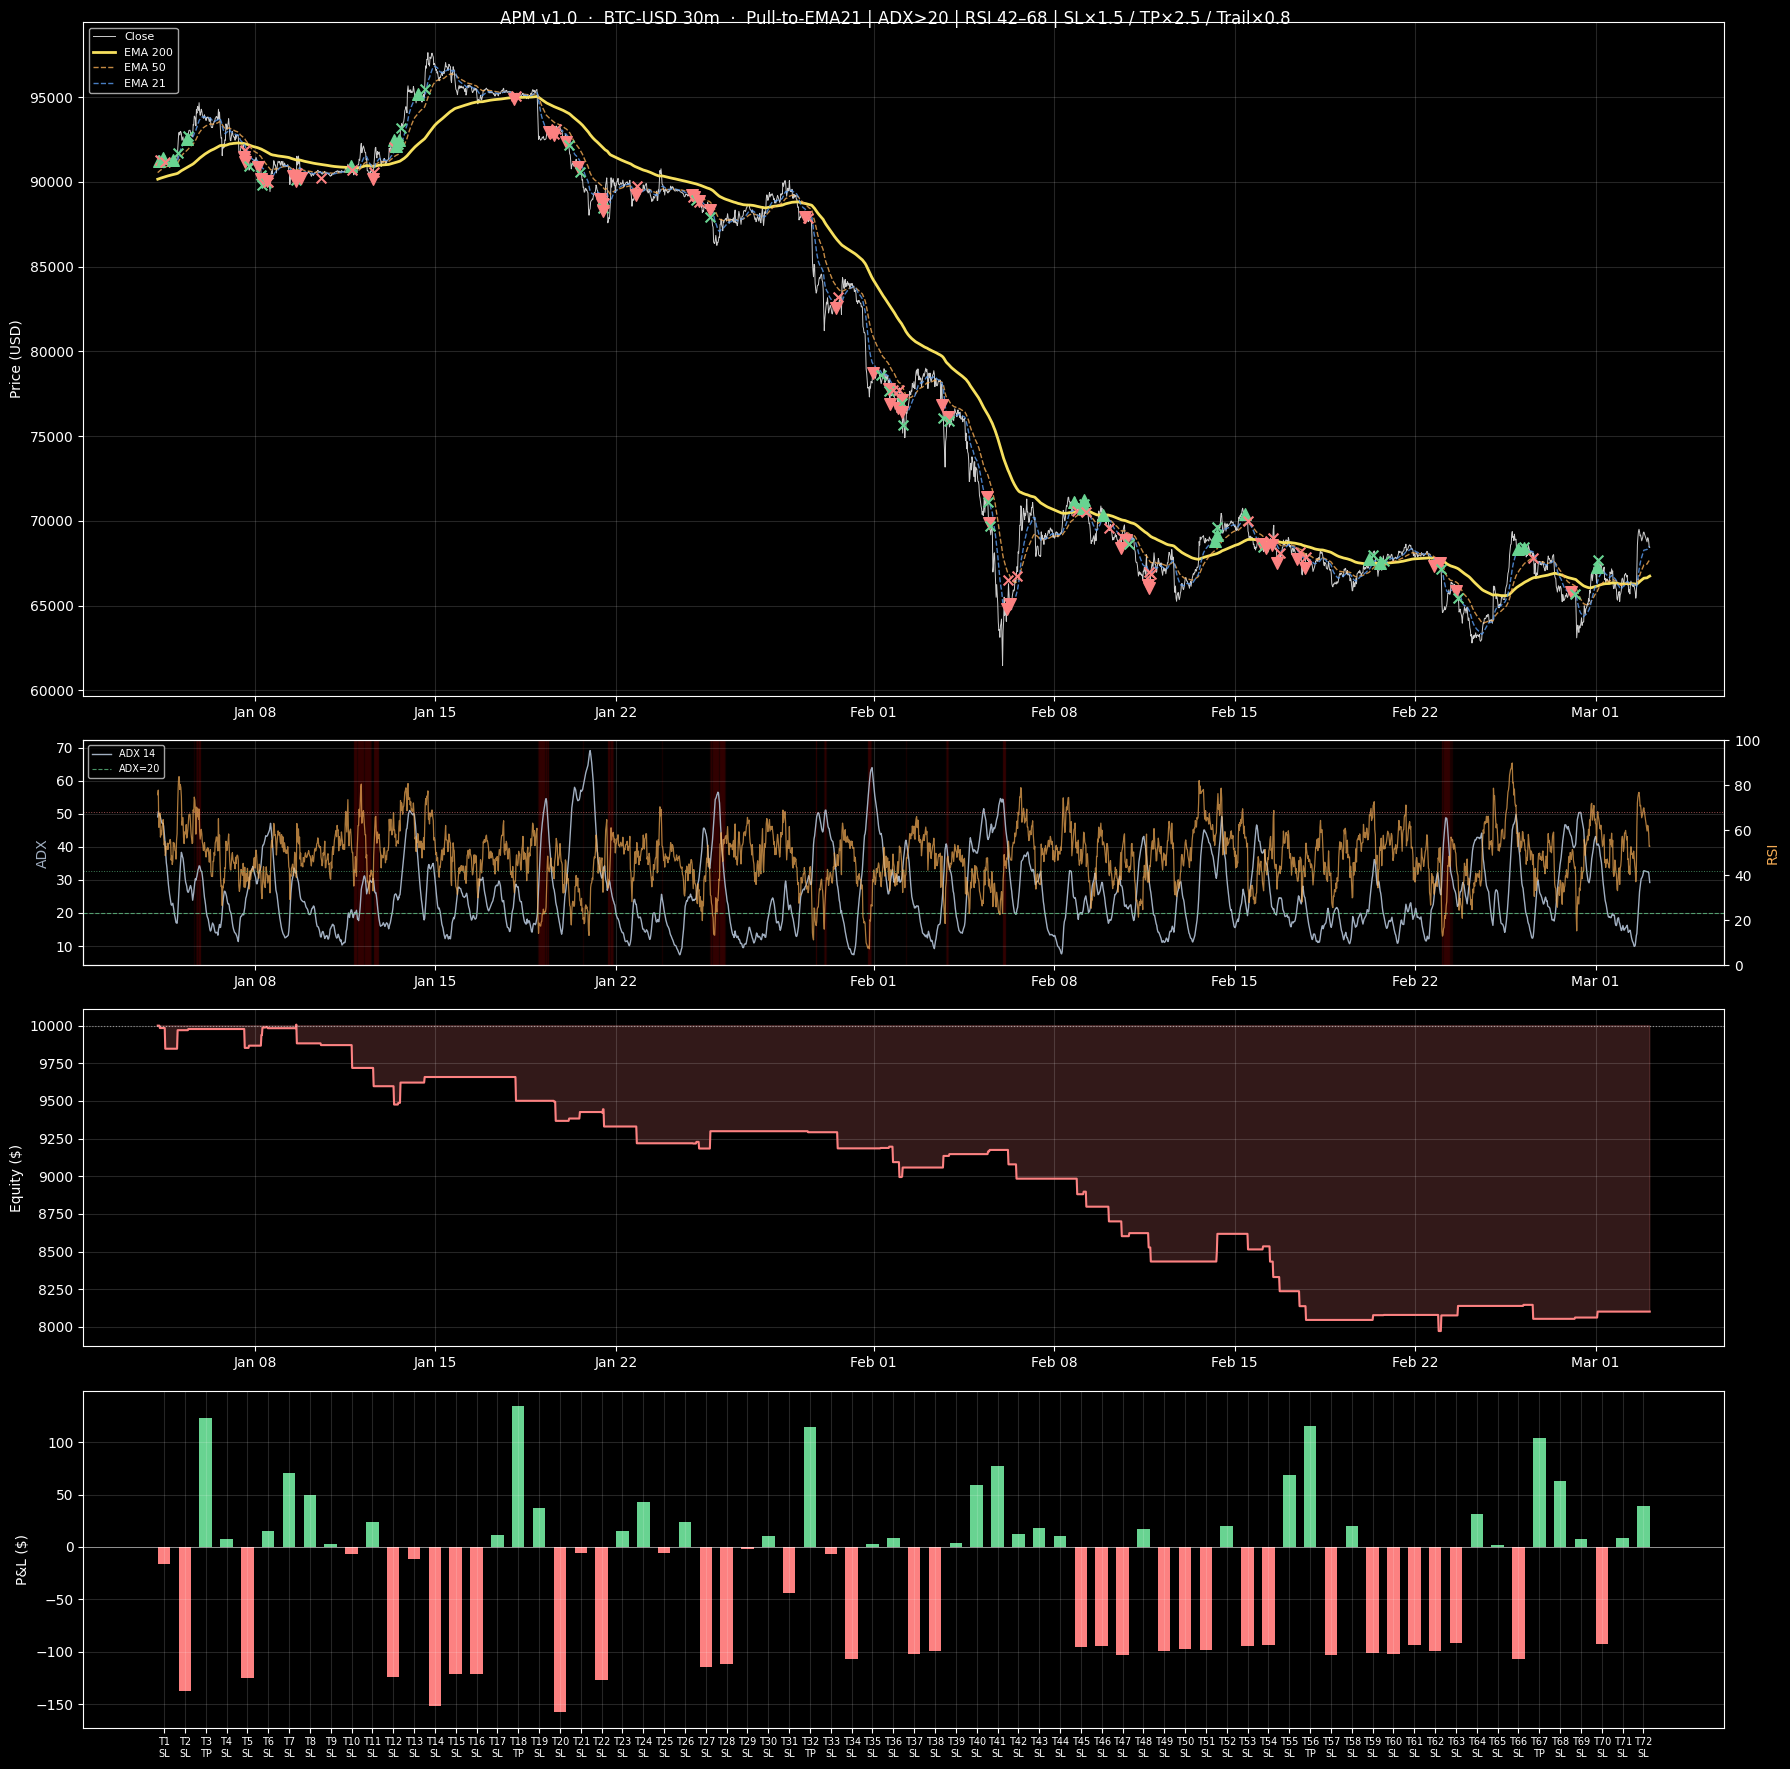

Chart saved → backtest_apm_btcusd_30m.png


In [8]:
# ── 7. Charts ─────────────────────────────────────────────────────────────────
ec_df = pd.DataFrame(equity_curve).set_index("time")
plt.style.use("dark_background")

fig, axes = plt.subplots(4, 1, figsize=(18, 18),
                          gridspec_kw={"height_ratios": [3, 1, 1.5, 1.5]})
fig.suptitle(
    f"APM v1.0  ·  {TICKER} {INTERVAL}  ·  Pull-to-EMA{EMA_FAST} | ADX>{ADX_THRESH} | RSI {RSI_LO_L}–{RSI_HI_L} | "
    f"SL×{SL_MULT} / TP×{TP_MULT} / Trail×{TRAIL_DIST}",
    fontsize=12)

# ── Panel 1 : Price + EMAs + entry/exit markers ───────────────────────────────
ax1 = axes[0]
ax1.plot(df.index, df["Close"],    color="#cccccc", lw=0.7, label="Close")
ax1.plot(df.index, df["EMA_SLOW"], color="#f6e05e", lw=2.0, label=f"EMA {EMA_SLOW}")
ax1.plot(df.index, df["EMA_MID"],  color="#f6ad55", lw=1.0, ls="--", alpha=0.8, label=f"EMA {EMA_MID}")
ax1.plot(df.index, df["EMA_FAST"], color="#5b9ef4", lw=1.0, ls="--", alpha=0.8, label=f"EMA {EMA_FAST}")

if not tdf.empty:
    for _, t in tdf.iterrows():
        w_col = "#68d391" if t["dollar_pnl"] >= 0 else "#fc8181"
        mrkr  = "^" if t["direction"] == "long" else "v"
        e_col = "#68d391" if t["direction"] == "long" else "#fc8181"
        ax1.scatter(t["entry_time"], t["entry"], marker=mrkr, color=e_col, s=70, zorder=5)
        ax1.scatter(t["exit_time"],  t["exit"],  marker="x",  color=w_col, s=50, zorder=5)

ax1.set_ylabel("Price (USD)")
ax1.legend(loc="upper left", fontsize=8)
ax1.grid(alpha=0.15)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# ── Panel 2 : ADX + RSI (dual axis) + panic shading ──────────────────────────
ax2     = axes[1]
ax2_rsi = ax2.twinx()
ax2.plot(df.index, df["ADX"], color="#a0aec0", lw=1.0, label=f"ADX {ADX_LEN}")
ax2.axhline(ADX_THRESH, color="#68d391", ls="--", lw=0.8, alpha=0.7, label=f"ADX={ADX_THRESH}")
ax2_rsi.plot(df.index, df["RSI"], color="#f6ad55", lw=0.9, alpha=0.7, label="RSI")
ax2_rsi.axhline(RSI_HI_L, color="#fc8181", ls=":", lw=0.7, alpha=0.6)
ax2_rsi.axhline(RSI_LO_L, color="#68d391", ls=":", lw=0.7, alpha=0.6)
ax2_rsi.set_ylim(0, 100)
for ts_p in df[df["IS_PANIC"]].index:
    ax2.axvspan(ts_p, ts_p, alpha=0.08, color="red")
ax2.set_ylabel("ADX",  color="#a0aec0")
ax2_rsi.set_ylabel("RSI", color="#f6ad55")
ax2.legend(loc="upper left", fontsize=7)
ax2.grid(alpha=0.15)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# ── Panel 3 : Equity curve ────────────────────────────────────────────────────
ax3 = axes[2]
final_val  = ec_df["equity"].iloc[-1]
eq_col     = "#68d391" if final_val >= INITIAL_CAPITAL else "#fc8181"
ax3.plot(ec_df.index, ec_df["equity"], color=eq_col, lw=1.5)
ax3.axhline(INITIAL_CAPITAL, color="white", ls=":", lw=0.8, alpha=0.5)
ax3.fill_between(ec_df.index, INITIAL_CAPITAL, ec_df["equity"],
                 where=ec_df["equity"] >= INITIAL_CAPITAL, alpha=0.2, color="#68d391")
ax3.fill_between(ec_df.index, INITIAL_CAPITAL, ec_df["equity"],
                 where=ec_df["equity"] < INITIAL_CAPITAL,  alpha=0.2, color="#fc8181")
ax3.set_ylabel("Equity ($)")
ax3.grid(alpha=0.15)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# ── Panel 4 : Per-trade P&L bars ─────────────────────────────────────────────
ax4 = axes[3]
if not tdf.empty:
    bar_c  = ["#68d391" if v >= 0 else "#fc8181" for v in tdf["dollar_pnl"]]
    ax4.bar(range(len(tdf)), tdf["dollar_pnl"], color=bar_c, width=0.6)
    ax4.axhline(0, color="white", lw=0.7, alpha=0.5)
    labels = [f"T{i+1}\n{r}" for i, r in enumerate(tdf["result"])]
    ax4.set_xticks(range(len(tdf)))
    ax4.set_xticklabels(labels, fontsize=7)
ax4.set_ylabel("P&L ($)")
ax4.grid(alpha=0.15)

plt.tight_layout()
out_png = f"backtest_apm_{TICKER.replace('-','').lower()}_{INTERVAL}.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved → {out_png}")

## 8 · Diagnosis & Parameter Sensitivity

**Observations from first run (BTC-USD 30m, 60d, Jan–Mar 2026)**

| Root cause | Evidence | Fix |
|---|---|---|
| TP too far → almost never hit | 5/72 TP exits; avg win only $39 vs target-implied ~$166 | Tighten TP to ATR×1.5 (1:1 R:R but rely on trail to extend good trades) |
| Trailing stop exits winners too early | Avg win $39 ≈ only 0.44× the avg loss; trail at 0.8×ATR is very tight | Raise TRAIL_ACT to 1.5 so trail activates later; test TRAIL_DIST at 1.0 |
| PB_PCT = 0.30% too permissive | 91 raw signals = 52/week — too many noise entries | Raise to 0.15% (tighter touch) or add min-body-size filter |
| No required bar-body minimum | Entry bar could be near-doji | Require `(close - open) / atr > 0.15` for body confirmation |

**Quick sensitivity test below tries tighter parameters.**

In [ ]:

# ── 8. Parameter sensitivity — tighter configuration ─────────────────────────
# Changes vs defaults:
#   PB_PCT      : 0.30 → 0.15   (tighter pullback touch required)
#   TP_MULT     : 2.50 → 1.50   (closer target → more TP exits)
#   TRAIL_ACT   : 1.00 → 1.50   (trail activates later → full TP has more room)
#   TRAIL_DIST  : 0.80 → 1.00   (looser trail → fewer premature exits)
#   Min body pct: new  → 0.15×ATR  (entry bar must have meaningful body)
#   ADX_THRESH  : 20   → 25     (stricter trend quality)

PB2      = 0.15
TP2      = 1.50
TACT2    = 1.50
TDIST2   = 1.00
ADX2     = 25
MIN_BODY = 0.15   # (close-open)/atr must exceed this for entry bar confirmation

tol2 = PB2 / 100.0

# Body confirmation
body_bull = (df["Close"] - df["Open"]) / df["ATR"] > MIN_BODY
body_bear = (df["Open"] - df["Close"]) / df["ATR"] > MIN_BODY

long_pb2  = (
    (df["Low"].shift(1) <= df["EMA_FAST"].shift(1) * (1 + tol2)) &
    (df["Close"] > df["EMA_FAST"]) & body_bull
)
short_pb2 = (
    (df["High"].shift(1) >= df["EMA_FAST"].shift(1) * (1 - tol2)) &
    (df["Close"] < df["EMA_FAST"]) & body_bear
)

df["LongSignal2"] = (
    long_pb2 &
    (df["Close"]    > df["EMA_SLOW"]) &
    (df["EMA_FAST"] > df["EMA_MID"]) &
    (df["RSI"] >= RSI_LO_L) & (df["RSI"] <= RSI_HI_L) &
    (df["Volume"] >= df["VOL_MA"] * VOL_MULT) &
    (df["ADX"] > ADX2) & ~df["IS_PANIC"]
) & TRADE_LONGS

df["ShortSignal2"] = (
    short_pb2 &
    (df["Close"]    < df["EMA_SLOW"]) &
    (df["EMA_FAST"] < df["EMA_MID"]) &
    (df["RSI"] >= RSI_LO_S) & (df["RSI"] <= RSI_HI_S) &
    (df["Volume"] >= df["VOL_MA"] * VOL_MULT) &
    (df["ADX"] > ADX2) & ~df["IS_PANIC"]
) & TRADE_SHORTS

print(f"v2 Long  signals : {df['LongSignal2'].sum():>4}")
print(f"v2 Short signals : {df['ShortSignal2'].sum():>4}")
print(f"v2 Total         : {df['LongSignal2'].sum() + df['ShortSignal2'].sum():>4}")

# ── Run simulation ────────────────────────────────────────────────────────────
eq2       = INITIAL_CAPITAL
pos2      = None
trades2   = []
eqcurve2  = []

for ts, row in df.iterrows():
    close = float(row["Close"])
    high  = float(row["High"])
    low   = float(row["Low"])
    atr   = float(row["ATR"])
    sd    = atr * SL_MULT   # stop distance stays the same (1.5×ATR)

    if pos2 is not None:
        d = pos2["direction"]
        if d == "long":
            if high > pos2["best"]: pos2["best"] = high
            if pos2["best"] >= pos2["entry"] + atr * TACT2:
                pos2["sl"] = max(pos2["sl"], pos2["best"] - atr * TDIST2)
            htp = high >= pos2["tp"];  hsl = low <= pos2["sl"]
            if htp or hsl:
                xp = pos2["tp"] if htp else pos2["sl"]
                pnl = (xp - pos2["entry"]) / pos2["entry"]
        else:
            if low < pos2["best"]: pos2["best"] = low
            if pos2["best"] <= pos2["entry"] - atr * TACT2:
                pos2["sl"] = min(pos2["sl"], pos2["best"] + atr * TDIST2)
            htp = low <= pos2["tp"];  hsl = high >= pos2["sl"]
            if htp or hsl:
                xp = pos2["tp"] if htp else pos2["sl"]
                pnl = (pos2["entry"] - xp) / pos2["entry"]

        if htp or hsl:
            dpnl = pnl * pos2["notional"] - pos2["notional"] * COMMISSION_PCT * 2
            eq2 += dpnl
            trades2.append({
                "direction": d, "entry_time": pos2["entry_time"], "exit_time": ts,
                "entry": pos2["entry"], "exit": xp,
                "result": "TP" if htp else "SL",
                "pnl_pct": round(pnl*100, 3),
                "dollar_pnl": round(dpnl, 2), "equity": round(eq2, 2),
            })
            pos2 = None

    if pos2 is None:
        sig = "long" if bool(row["LongSignal2"]) else ("short" if bool(row["ShortSignal2"]) else None)
        if sig:
            rc = eq2 * RISK_PCT; qty = rc / sd; notional = qty * close
            sl = close - sd if sig == "long" else close + sd
            tp = close + atr * TP2 if sig == "long" else close - atr * TP2
            pos2 = {"direction": sig, "entry": close, "entry_time": ts,
                    "sl": sl, "tp": tp, "best": close, "notional": notional}

    eqcurve2.append({"time": ts, "equity": eq2})

t2df = pd.DataFrame(trades2)
print(f"\nv2 trades executed: {len(t2df)}")

# ── Stats comparison ──────────────────────────────────────────────────────────
def stats_block(tdf_, eqc_, label):
    if tdf_.empty:
        print(f"[{label}] No trades."); return
    w = tdf_[tdf_["dollar_pnl"] > 0]; l = tdf_[tdf_["dollar_pnl"] <= 0]
    wr  = len(w)/len(tdf_)*100
    fin = tdf_["equity"].iloc[-1]
    gp  = w["dollar_pnl"].sum()   if not w.empty else 0
    gl  = l["dollar_pnl"].sum()   if not l.empty else 0
    pf  = gp/abs(gl)              if gl != 0     else float("inf")
    mdd = ((pd.Series([e["equity"] for e in eqc_]) -
            pd.Series([e["equity"] for e in eqc_]).cummax()) /
           pd.Series([e["equity"] for e in eqc_]).cummax() * 100).min()
    tp_c = (tdf_["result"]=="TP").sum()
    aw   = w["dollar_pnl"].mean() if not w.empty else 0
    al   = l["dollar_pnl"].mean() if not l.empty else 0
    rr   = aw/abs(al)             if al != 0     else float("inf")
    ret  = (fin/INITIAL_CAPITAL-1)*100
    print(f"{'='*54}")
    print(f"  {label}")
    print(f"{'='*54}")
    print(f"  Return        : {ret:>+9.2f} %   Max DD: {mdd:.2f} %")
    print(f"  Profit factor : {pf:>9.2f}   Trades: {len(tdf_)}")
    print(f"  Win rate      : {wr:>8.1f} %   TP exits: {tp_c} / {len(tdf_)}")
    print(f"  Avg win  $    : ${aw:>+9,.2f}   Avg loss $: ${al:>+9,.2f}   R:R: {rr:.2f}")
    print(f"{'='*54}")

stats_block(tdf,   equity_curve, f"APM v1 defaults   (PB={PB_PCT}% TP×{TP_MULT} ADX>{ADX_THRESH})")
print()
stats_block(t2df, eqcurve2,    f"APM v1 tighter    (PB={PB2}%  TP×{TP2}  ADX>{ADX2} +body)")
